In [1]:
import os
import sys
import numpy as np
import sympy
import math
from scipy.special import erf
from scipy.integrate import quad
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import matplotlib.colors as colors # Import the colors module
from mpl_toolkits.mplot3d import Axes3D # For 3D plots
import plotly.graph_objects as go # For interactive 3D plots (optional, but good for exploration)
import plotly.io as pio

import darkfield
from darkfield import rossendorfer_farbenliste as rofl
from  darkfield.rossendorfer_farbenliste import colors_from_img as arofl

output_dir = './paper_figs/'

In [2]:
# --- Define the constants ---
omega_val = 8766
barw_val = (0.85 * 1.5) * 5.07 # 0.5866
kappa_val = 1/4 # <--- This was the missing definition in the execution context


In [3]:
2.5280/(0.85*5.07)

0.5866109757512473

In [4]:
# --- 1. Define the symbolic dNdthetax function ---
omega, Thetaxout, barw, thetax, mu, M, Theta, kappa = sympy.symbols('omega Thetaxout barw thetax mu M Theta kappa')

def dNdthetax_sympy(omega_sym, Thetaxout_sym, barw_sym, thetax_sym, mu_sym):
    sum_term = 0
    for sigma_val in [-1, 1]:
        sigma = sympy.S(sigma_val)
        term1 = sympy.erf((barw_sym * omega_sym * (sigma * Thetaxout_sym - thetax_sym)) / (4 * sympy.sqrt(2)))
        term2 = sympy.erf((barw_sym * omega_sym * (sigma * sympy.sqrt(mu_sym) * Thetaxout_sym - thetax_sym)) / (4 * sympy.sqrt(2)))
        sum_term += sigma * (term1 - term2)
    result = (1 / (omega_sym * Thetaxout_sym)) * (sum_term ** 2)
    return result

dNdthetax_expr = dNdthetax_sympy(omega, Thetaxout, barw, thetax, mu)


# --- 2. Perform the symbolic substitutions ---
substitutions = {
    sympy.sqrt(mu): M * sympy.S('1e-2'),
    Thetaxout: Theta * sympy.S('1e-6'),
    omega: omega_val,
    barw: barw_val
}

dNdthetax_substituted = dNdthetax_expr.subs(substitutions)



# --- 3. Create the lambdified function for numerical integration ---
# omega and barw are no longer arguments as they've been substituted numerically
integrand_func = sympy.lambdify((thetax, M, Theta), dNdthetax_substituted, 'numpy')

# --- 4. Define the function to calculate ResOpt for given M and Theta ---
def calculate_ResOpt(M_current, Theta_current):
    # Numerical calculations for substitution values and integration limits
    sqrt_mu_limit_val = M_current * 1e-2
    Thetaxout_limit_val = Theta_current * 1e-6

    # Handle boundary conditions that would lead to non-physical results or NaNs
    if Thetaxout_limit_val <= 0: # This means Theta <= 0
        return np.nan

    if sqrt_mu_limit_val < 0: # This means M < 0
        return np.nan

    lower_limit_num = -kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val
    upper_limit_num = kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val

    # Ensure valid integration interval (lower <= upper)
    if lower_limit_num > upper_limit_num:
        lower_limit_num, upper_limit_num = upper_limit_num, lower_limit_num

    try:
        # Pass M_current and Theta_current as arguments to the lambdified function
        result, abserr = quad(integrand_func, lower_limit_num, upper_limit_num,
                              args=(M_current, Theta_current),
                              limit=500, # Increased limit for potentially challenging integrals
                              epsabs=1.49e-08,
                              epsrel=1.49e-08)
        return result
    except Exception as e:
        return np.nan # Return NaN if integration fails

In [5]:
# # --- Output dNdthetax_substituted in LaTeX format ---
# print("\n--- LaTeX for dNdthetax_substituted (after ALL substitutions) ---")
# print(sympy.latex(dNdthetax_substituted))
# print("-" * 30)
# # --- Output dNdthetax_expr in LaTeX format ---
# print("--- LaTeX for dNdthetax_expr ---")
# print(sympy.latex(dNdthetax_expr))
# print("-" * 30)



$$
\Large
\frac{dN}{d\theta_x} := \frac{1}{\omega \theta_{x,out}} \left( \sum_{\sigma \in \{-1,1\}} \sigma \left[ \text{erf}\left(\frac{\bar{w}\omega(\sigma\theta_{x,out}-\theta_x)}{2\sqrt{2}}\right) - \text{erf}\left(\frac{\bar{w}\omega(\sigma\sqrt{\mu}\theta_{x,out}-\theta_x)}{2\sqrt{2}}\right) \right] \right)^2
$$

$$
\Large
\int_{-\kappa\sqrt{\mu}\theta_{x,out}}^{\kappa\sqrt{\mu}\theta_{x,out}} \frac{dN}{d\theta_x}\, d\theta_x
$$

In [6]:
plt.rc('font',   size     =18)          # controls default text sizes
plt.rc('axes',   titlesize=30)  # fontsize of the axes title
plt.rc('axes',   labelsize=24)          # fontsize of the x and y labels
plt.rc('xtick',  labelsize=28) # fontsize of the tick labels
plt.rc('ytick',  labelsize=24) # fontsize of the tick labels
plt.rc('legend', fontsize =16)          # legend fontsize

In [7]:

# --- 5. Generate data for plotting ---
M_range_3d = np.linspace(0, 100, 50)
Theta_range_3d = np.linspace(0.1, 1000, 50)
M_grid_3d, Theta_grid_3d = np.meshgrid(M_range_3d, Theta_range_3d)
Z_3d = np.zeros_like(M_grid_3d, dtype=float)

print("Calculating 3D plot data...")
for i in range(M_grid_3d.shape[0]):
    for j in range(M_grid_3d.shape[1]):
        Z_3d[i, j] = calculate_ResOpt(M_grid_3d[i, j], Theta_grid_3d[i, j])
print("3D plot data calculated.")

M_range_density = np.linspace(0, 70, 70)
Theta_range_density = np.linspace(0.1, 400, 70)
M_grid_density, Theta_grid_density = np.meshgrid(M_range_density, Theta_range_density)
Z_density = np.zeros_like(M_grid_density, dtype=float)

print("Calculating density plot data...")
for i in range(M_grid_density.shape[0]):
    for j in range(M_grid_density.shape[1]):
        Z_density[i, j] = calculate_ResOpt(M_grid_density[i, j], Theta_grid_density[i, j])
print("Density plot data calculated.")

Calculating 3D plot data...
3D plot data calculated.
Calculating density plot data...
Density plot data calculated.



Max Original Z_density value: 1.9342e-05
Max Normalized Z_density value: 1.0000
Calculated contour levels (ratio to max): [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]


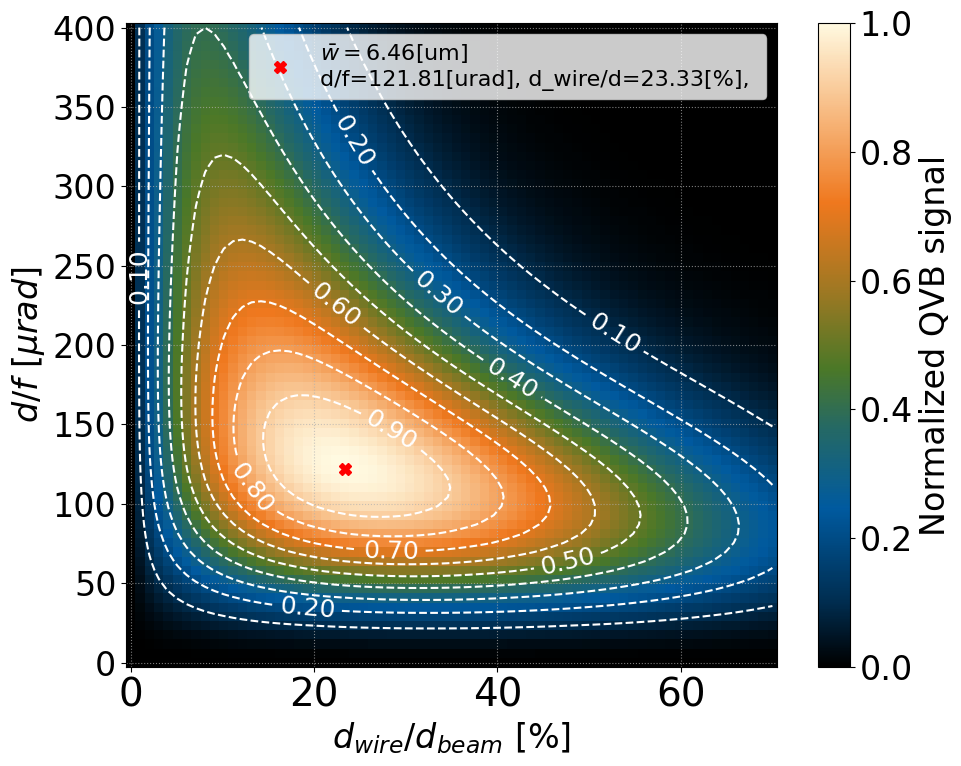

In [8]:
fig_density_mpl, ax_density_mpl = plt.subplots(figsize=(10, 8))

original_max_signal_value = np.nanmax(Z_density)

# Create a normalized version of Z_density for consistent plotting and contouring
Z_density_normalized = Z_density / original_max_signal_value
max_normalized_signal_value = np.nanmax(Z_density_normalized)

# Define Isocontour Levels as ratios (e.g., 90%, 80%, etc. of max normalized signal)

percentage_levels = [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
# Since Z_density_normalized's max is 1, these percentages *are* the contour levels.
contour_levels_ratio = [max_normalized_signal_value * level for level in percentage_levels]

# Filter out any levels that are less than or equal to 0 and sort
contour_levels_ratio = [level for level in contour_levels_ratio if level > 0]
contour_levels_ratio.sort() # Ensure strictly increasing order

print(f"\nMax Original Z_density value: {original_max_signal_value:.4e}") # Using scientific notation for small numbers
print(f"Max Normalized Z_density value: {max_normalized_signal_value:.4f}")
print(f"Calculated contour levels (ratio to max): {contour_levels_ratio}")


heatmap = ax_density_mpl.pcolormesh(M_grid_density, Theta_grid_density, Z_density_normalized, cmap=rofl.cmap(), shading='auto')#, norm=log_norm)
fig_density_mpl.colorbar(heatmap, ax=ax_density_mpl, label='Normalized QVB signal')


# Overlay the Isocontours using Z_density_normalized ---
contours = ax_density_mpl.contour(M_grid_density, Theta_grid_density, Z_density_normalized, levels=contour_levels_ratio,colors='white', linestyles='--', linewidths=1.5)

# Add labels to the contour lines
ax_density_mpl.clabel(contours, inline=True, fmt='%.2f') # Now '%.2f' will show values like 0.90, 0.80, etc.

# Find the index of the maximum value in Z_density_normalized
# np.argmax returns the flattened index, so we need np.unravel_index to get 2D indices
max_idx_flat = np.nanargmax(Z_density_normalized)
row_idx, col_idx = np.unravel_index(max_idx_flat, Z_density_normalized.shape)

# Get the M and Theta coordinates corresponding to this max index
max_m_coord = M_grid_density[row_idx, col_idx]
max_theta_coord = Theta_grid_density[row_idx, col_idx]

# 3. Plot the marker at the max coordinates
# Create the label string correctly:
labeled = f'{r"$\bar{w} = $"}{barw_val:.2f}[um]\n' \
               f'd/f={max_theta_coord:.2f}[urad], d_wire/d={max_m_coord:.2f}[%], '
ax_density_mpl.plot(max_m_coord, max_theta_coord, 'X', markersize=8, color='red', markeredgewidth=1,label=labeled)

# Mark the specified maximum point (M=20, Theta=160)
marker_m = 20
marker_theta = 160
#ax_density_mpl.plot(marker_m, marker_theta, 'x', markersize=12, color='red', markeredgewidth=2, label=f'd/f={marker_theta}[urad], d_wire/d={marker_m}[%]')

# Set plot title and labels
ax_density_mpl.set_xlabel(r'$d_{wire}/d_{beam}~[\%]$')
ax_density_mpl.set_ylabel(r'$d/f~[\mu rad]$')
ax_density_mpl.grid(True, linestyle=':', alpha=0.7)
ax_density_mpl.legend(loc='upper right')

plt.tight_layout()

#plt.savefig(os.path.join(output_dir, 'normalized_qvb_barw.png'), bbox_inches = 'tight')
plt.show()


Max Original Z_density value: 1.9342e-05
Max Normalized Z_density value: 1.0000
Calculated contour levels (ratio to max): [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]


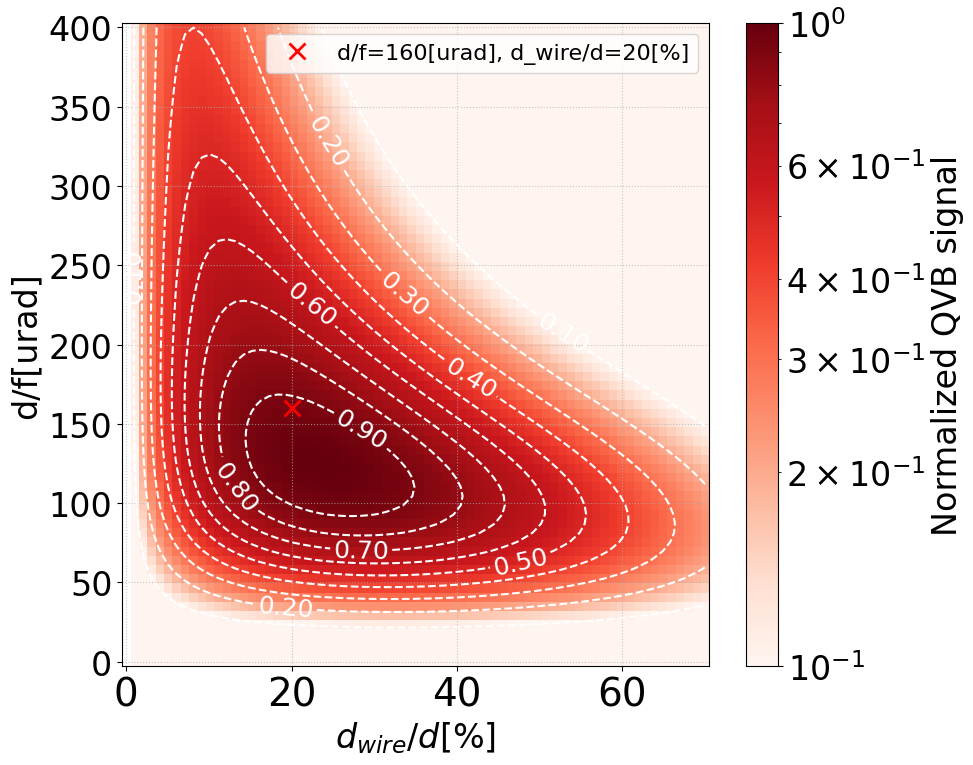

In [9]:

fig_density_mpl, ax_density_mpl = plt.subplots(figsize=(10, 8))

# --- IMPORTANT CHANGE 1: Use Normalized Z_density for contour calculations and plotting ---
# Calculate the maximum signal value from the original Z_density
original_max_signal_value = np.nanmax(Z_density)
vmin_log = 1e-1 # Ensure vmin is > 0
vmax_log = 1e0
log_norm = colors.LogNorm(vmin=vmin_log, vmax=vmax_log)
# Create a normalized version of Z_density for consistent plotting and contouring
Z_density_normalized = Z_density / original_max_signal_value

# Find the maximum signal value in the *normalized* Z_density, ignoring NaNs
# This will be approximately 1.0 (or whatever your max normalization is)
max_normalized_signal_value = np.nanmax(Z_density_normalized)

# Define Isocontour Levels as ratios (e.g., 90%, 80%, etc. of max normalized signal)
# Now these percentages directly represent the desired ratio
# These levels should be between 0 and 1.
percentage_levels = [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
# Since Z_density_normalized's max is 1, these percentages *are* the contour levels.
contour_levels_ratio = [max_normalized_signal_value * level for level in percentage_levels]

# Filter out any levels that are less than or equal to 0 and sort
contour_levels_ratio = [level for level in contour_levels_ratio if level > 0]
contour_levels_ratio.sort() # Ensure strictly increasing order

print(f"\nMax Original Z_density value: {original_max_signal_value:.4e}") # Using scientific notation for small numbers
print(f"Max Normalized Z_density value: {max_normalized_signal_value:.4f}")
print(f"Calculated contour levels (ratio to max): {contour_levels_ratio}")


# Create the Heatmap using pcolormesh with the custom Matplotlib colormap
# The pcolormesh now uses the Z_density_normalized directly, so its colorbar represents 0-1
# Assuming rofl.cmap() exists or replace with a standard colormap like 'viridis'


heatmap = ax_density_mpl.pcolormesh(M_grid_density, Theta_grid_density, Z_density_normalized, cmap='Reds', shading='auto', norm=log_norm)
fig_density_mpl.colorbar(heatmap, ax=ax_density_mpl, label='Normalized QVB signal')


# --- IMPORTANT CHANGE 2: Overlay the Isocontours using Z_density_normalized ---
contours = ax_density_mpl.contour(M_grid_density, Theta_grid_density, Z_density_normalized, levels=contour_levels_ratio,colors='white', linestyles='--', linewidths=1.5)

# Add labels to the contour lines
# --- IMPORTANT CHANGE 3: Format labels to show ratio, and consider precision ---
ax_density_mpl.clabel(contours, inline=True, fmt='%.2f') # Now '%.2f' will show values like 0.90, 0.80, etc.

# Mark the specified maximum point (M=20, Theta=160)
marker_m = 20
marker_theta = 160
ax_density_mpl.plot(marker_m, marker_theta, 'x', markersize=12, color='red', markeredgewidth=2, label=f'd/f={marker_theta}[urad], d_wire/d={marker_m}[%]')
# ax_density_mpl.plot(marker_m, marker_theta, 'o', markersize=12, color='black', markeredgewidth=2, label=f'd/f={marker_theta}[urad], d_wire/d={marker_m}[%]')

# Set plot title and labels
ax_density_mpl.set_xlabel(r'$d_{wire}/d [\%]$')
ax_density_mpl.set_ylabel('d/f[urad]')
ax_density_mpl.grid(True, linestyle=':', alpha=0.7)
ax_density_mpl.legend()

plt.tight_layout()
plt.show()

Using initial guess: omega_val=8766, barw_val=2.5279527, kappa_val=0.25
Calculating 3D plot data...
3D plot data calculated.
Calculating density plot data...
Density plot data calculated.

Max Z_density value (original): 1.9347e-05
Calculated contour levels (ratio to max): [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]


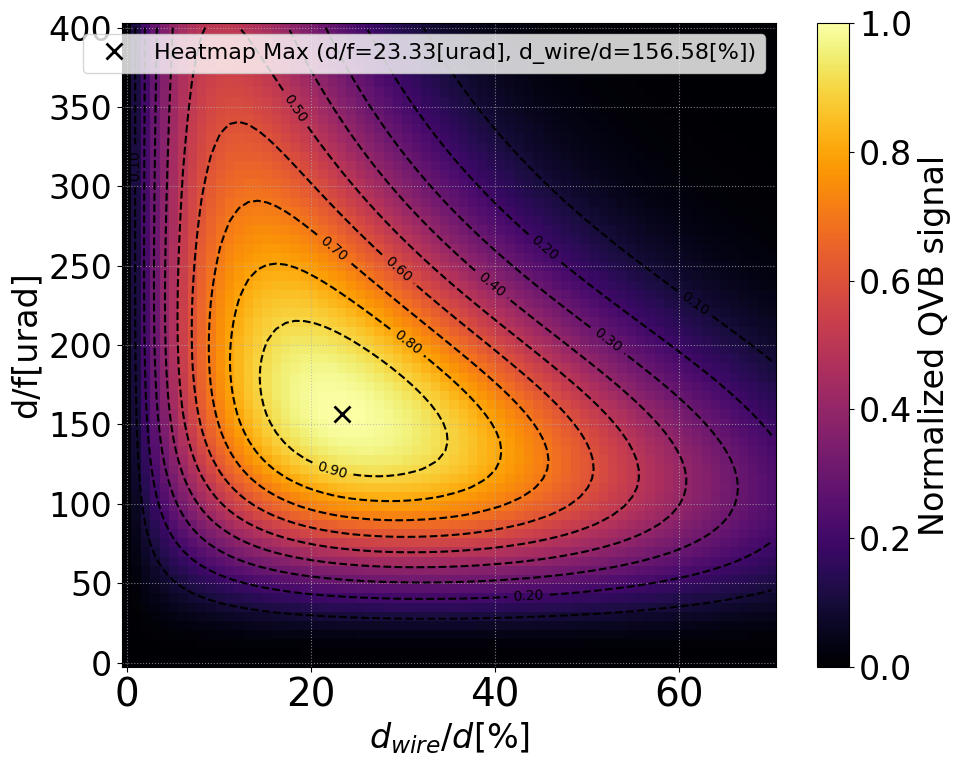

In [10]:

# --- Define Global Constants (Your initial guess) ---
omega_val = 8766
barw_val = (0.85 * 0.5866) * 5.07
kappa_val = 1/4

print(f"Using initial guess: omega_val={omega_val}, barw_val={barw_val}, kappa_val={kappa_val}")

# --- 1. Define the symbolic dNdthetax function ---
omega, Thetaxout, barw, thetax, mu, M, Theta, kappa = sympy.symbols('omega Thetaxout barw thetax mu M Theta kappa')

def dNdthetax_sympy(omega_sym, Thetaxout_sym, barw_sym, thetax_sym, mu_sym):
    sum_term = 0
    for sigma_val in [-1, 1]:
        sigma = sympy.S(sigma_val)
        term1 = sympy.erf((barw_sym * omega_sym * (sigma * Thetaxout_sym - thetax_sym)) / (2 * sympy.sqrt(2)))
        term2 = sympy.erf((barw_sym * omega_sym * (sigma * sympy.sqrt(mu_sym) * Thetaxout_sym - thetax_sym)) / (2 * sympy.sqrt(2)))
        sum_term += sigma * (term1 - term2)
    result = (1 / (omega_sym * Thetaxout_sym)) * (sum_term ** 2)
    return result

dNdthetax_expr = dNdthetax_sympy(omega, Thetaxout, barw, thetax, mu)


# --- 2. Perform the symbolic substitutions ---
substitutions = {
    sympy.sqrt(mu): M * sympy.S('1e-2'),
    Thetaxout: Theta * sympy.S('1e-6'),
    omega: omega_val,  # Now uses the numerical value
    barw: barw_val     # Now uses the numerical value
}

dNdthetax_substituted = dNdthetax_expr.subs(substitutions)


# --- 3. Create the lambdified function for numerical integration ---
integrand_func = sympy.lambdify((thetax, M, Theta), dNdthetax_substituted, 'numpy')

# --- 4. Define the function to calculate ResOpt for given M and Theta ---
def calculate_ResOpt(M_current, Theta_current):
    # Numerical calculations for substitution values and integration limits
    sqrt_mu_limit_val = M_current * 1e-2
    Thetaxout_limit_val = Theta_current * 1e-6

    # Handle boundary conditions that would lead to non-physical results or NaNs
    if Thetaxout_limit_val <= 0: # This means Theta <= 0
        return np.nan

    if sqrt_mu_limit_val < 0: # This means M < 0
        return np.nan

    lower_limit_num = -kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val
    upper_limit_num = kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val

    # Ensure valid integration interval (lower <= upper)
    if lower_limit_num > upper_limit_num:
        lower_limit_num, upper_limit_num = upper_limit_num, lower_limit_num
    
    # Check for zero integration range (can happen if limits are identical)
    if np.isclose(lower_limit_num, upper_limit_num):
        return 0.0 # Integral over a zero width is zero

    try:
        # Pass M_current and Theta_current as arguments to the lambdified function
        result, abserr = quad(integrand_func, lower_limit_num, upper_limit_num,
                              args=(M_current, Theta_current),
                              limit=500, # Increased limit for potentially challenging integrals
                              epsabs=1.49e-08,
                              epsrel=1.49e-08)
        return result
    except Exception as e:
        # print(f"Integration failed for M={M_current}, Theta={Theta_current}: {e}") # Optional: for debugging
        return np.nan # Return NaN if integration fails

# --- 5. Generate data for plotting ---
# Using a slightly coarser grid for Z_3d to speed up initial run
M_range_3d = np.linspace(0, 100, 25)
Theta_range_3d = np.linspace(0.1, 1000, 25)
M_grid_3d, Theta_grid_3d = np.meshgrid(M_range_3d, Theta_range_3d)
Z_3d = np.zeros_like(M_grid_3d, dtype=float)

print("Calculating 3D plot data...")
for i in range(M_grid_3d.shape[0]):
    for j in range(M_grid_3d.shape[1]):
        Z_3d[i, j] = calculate_ResOpt(M_grid_3d[i, j], Theta_grid_3d[i, j])
print("3D plot data calculated.")

# Using your specified density grid for Z_density
M_range_density = np.linspace(0, 70, 70)
Theta_range_density = np.linspace(0.1, 400, 70)
M_grid_density, Theta_grid_density = np.meshgrid(M_range_density, Theta_range_density)
Z_density = np.zeros_like(M_grid_density, dtype=float)

print("Calculating density plot data...")
for i in range(M_grid_density.shape[0]):
    for j in range(M_grid_density.shape[1]):
        Z_density[i, j] = calculate_ResOpt(M_grid_density[i, j], Theta_grid_density[i, j])
print("Density plot data calculated.")

# --- Prepare data for plotting (normalized Z_density) ---
# Find the maximum signal value in the calculated Z_density, ignoring NaNs
max_original_Z_density_value = np.nanmax(Z_density)

if np.isclose(max_original_Z_density_value, 0) or np.isnan(max_original_Z_density_value):
    print("Warning: Z_density maximum is zero or NaN. Cannot normalize. Plot might be empty or problematic.")
    Z_density_normalized = np.zeros_like(Z_density) # Avoid division by zero
else:
    Z_density_normalized = Z_density / max_original_Z_density_value

# Define Isocontour Levels (e.g., 90%, 80%, etc. drop from max)
percentage_levels = [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
contour_levels_ratio = [np.nanmax(Z_density_normalized) * level for level in percentage_levels]
contour_levels_ratio = [level for level in contour_levels_ratio if level > 0]
contour_levels_ratio.sort()

print(f"\nMax Z_density value (original): {max_original_Z_density_value:.4e}")
print(f"Calculated contour levels (ratio to max): {contour_levels_ratio}")

# --- Matplotlib Density Plot with Isocontours and Marker ---
fig_density_mpl, ax_density_mpl = plt.subplots(figsize=(10, 8))


heatmap = ax_density_mpl.pcolormesh(M_grid_density, Theta_grid_density, Z_density_normalized, cmap='inferno', shading='auto')
fig_density_mpl.colorbar(heatmap, ax=ax_density_mpl, label='Normalized QVB signal')

# Overlay the Isocontours
# Ensure contour levels are meaningful for the normalized data
contours = ax_density_mpl.contour(M_grid_density, Theta_grid_density, Z_density_normalized,
                                  levels=contour_levels_ratio, colors='black', linestyles='--', linewidths=1.5)

# Add labels to the contour lines
ax_density_mpl.clabel(contours, inline=True, fontsize=10, fmt='%.2f')

# --- Plot marker at heatmap max ---
# Find the index of the maximum value in Z_density_normalized
max_idx_flat = np.nanargmax(Z_density_normalized)
row_idx, col_idx = np.unravel_index(max_idx_flat, Z_density_normalized.shape)

# Get the M and Theta coordinates corresponding to this max index
max_m_coord = M_grid_density[row_idx, col_idx]
max_theta_coord = Theta_grid_density[row_idx, col_idx]

# Plot the marker at the max coordinates
ax_density_mpl.plot(max_m_coord, max_theta_coord, 'x', markersize=12, color='black', markeredgewidth=2,
                    label=f'Heatmap Max (d/f={max_m_coord:.2f}[urad], d_wire/d={max_theta_coord:.2f}[%])')

# Set plot title and labels
ax_density_mpl.set_xlabel(r'$d_{wire}/d [\%]$')
ax_density_mpl.set_ylabel('d/f[urad]')
ax_density_mpl.grid(True, linestyle=':', alpha=0.7)
ax_density_mpl.legend()

plt.tight_layout()


output_dir = './paper_figs/'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
#     print(f"Directory '{output_dir}' created.")
# else:
#     print(f"Directory '{output_dir}' already exists.")

# plt.savefig(os.path.join(output_dir, 'normalized_qvb.png'), bbox_inches='tight')

plt.show() # Display the plot

In [11]:

# --- Define Global Constants (Initial Guess for Optimization) ---
# These will be updated by the optimizer
global omega_val, barw_val, kappa_val
omega_val = 8766
barw_val = (0.85 * 0.5866) * 5.07
kappa_val = 1/4

print(f"Starting optimization with initial guess: omega_val={omega_val}, barw_val={barw_val}, kappa_val={kappa_val}")

# --- Target Max Location ---
target_M = 20
target_Theta = 160
print(f"Target maximum at M={target_M}, Theta={target_Theta}")

# --- 1. Define the symbolic dNdthetax function ---
omega, Thetaxout, barw, thetax, mu, M, Theta, kappa = sympy.symbols('omega Thetaxout barw thetax mu M Theta kappa')

def dNdthetax_sympy(omega_sym, Thetaxout_sym, barw_sym, thetax_sym, mu_sym):
    sum_term = 0
    for sigma_val in [-1, 1]:
        sigma = sympy.S(sigma_val)
        term1 = sympy.erf((barw_sym * omega_sym * (sigma * Thetaxout_sym - thetax_sym)) / (2 * sympy.sqrt(2)))
        term2 = sympy.erf((barw_sym * omega_sym * (sigma * sympy.sqrt(mu_sym) * Thetaxout_sym - thetax_sym)) / (2 * sympy.sqrt(2)))
        sum_term += sigma * (term1 - term2)
    result = (1 / (omega_sym * Thetaxout_sym)) * (sum_term ** 2)
    return result

dNdthetax_expr = dNdthetax_sympy(omega, Thetaxout, barw, thetax, mu)

# --- 4. Define the function to calculate ResOpt for given M and Theta ---
# This function now relies on the global omega_val, barw_val, kappa_val
def calculate_ResOpt(M_current, Theta_current):
    # Perform symbolic substitutions locally within this call as well,
    # ensuring the latest global values are used
    local_substitutions = {
        sympy.sqrt(mu): M_current * sympy.S('1e-2'),
        Thetaxout: Theta_current * sympy.S('1e-6'),
        omega: omega_val,
        barw: barw_val
    }
    dNdthetax_local_substituted = dNdthetax_expr.subs(local_substitutions)

    # Re-lambdify with the current M_current, Theta_current as fixed values
    # This is inefficient, better to lambdify once with (thetax, M, Theta)
    # and pass M_current, Theta_current as args for integrand_func.
    # The current lambda-fication (integrand_func) is already set up for this.

    # Numerical calculations for integration limits
    sqrt_mu_limit_val = M_current * 1e-2
    Thetaxout_limit_val = Theta_current * 1e-6

    # Handle boundary conditions
    if Thetaxout_limit_val <= 0 or sqrt_mu_limit_val < 0:
        return np.nan

    lower_limit_num = -kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val
    upper_limit_num = kappa_val * sqrt_mu_limit_val * Thetaxout_limit_val

    if lower_limit_num > upper_limit_num:
        lower_limit_num, upper_limit_num = upper_limit_num, lower_limit_num

    if np.isclose(lower_limit_num, upper_limit_num):
        return 0.0

    try:
        # integrand_func was defined globally, it expects (thetax, M, Theta)
        # We pass M_current and Theta_current as args for the quad function
        result, abserr = quad(integrand_func, lower_limit_num, upper_limit_num,
                              args=(M_current, Theta_current), # Pass the current M and Theta
                              limit=500,
                              epsabs=1.49e-08,
                              epsrel=1.49e-08)
        return result
    except Exception as e:
        return np.nan

# --- Objective Function for Optimization ---
def objective_function(params):
    global omega_val, barw_val, kappa_val
    current_omega, current_barw, current_kappa = params

    # Update global parameters for the current iteration
    omega_val = current_omega
    barw_val = current_barw
    kappa_val = current_kappa

    # --- Re-generate data for finding max location (coarser grid for speed) ---
    # Adjust grid resolution for optimization speed
    opt_grid_points = 25 # Fewer points for faster iterations
    M_range_opt = np.linspace(0, 70, opt_grid_points) # Adjust ranges if max is outside
    Theta_range_opt = np.linspace(0.1, 400, opt_grid_points)
    M_grid_opt, Theta_grid_opt = np.meshgrid(M_range_opt, Theta_range_opt)
    Z_opt = np.zeros_like(M_grid_opt, dtype=float)

    # Use nested loops for calculating Z_opt values
    for i in range(M_grid_opt.shape[0]):
        for j in range(M_grid_opt.shape[1]):
            Z_opt[i, j] = calculate_ResOpt(M_grid_opt[i, j], Theta_grid_opt[i, j])

    # Handle cases where Z_opt might be all NaNs or zeros
    if np.all(np.isnan(Z_opt)) or np.all(Z_opt == 0):
        return 1e10 # Return a very high error if no valid data

    # Find the maximum value and its coordinates
    max_idx_flat = np.nanargmax(Z_opt)
    row_idx, col_idx = np.unravel_index(max_idx_flat, Z_opt.shape)
    actual_max_M = M_grid_opt[row_idx, col_idx]
    actual_max_Theta = Theta_grid_opt[row_idx, col_idx]

    # Calculate the Euclidean distance from the target
    error = np.sqrt((actual_max_M - target_M)**2 + (actual_max_Theta - target_Theta)**2)

    print(f"Iter: omega={current_omega:.2e}, barw={current_barw:.2e}, kappa={current_kappa:.2f} "
          f"-> Max at M={actual_max_M:.2f}, Theta={actual_max_Theta:.2f}. Error={error:.4f}")

    return error

Starting optimization with initial guess: omega_val=8766, barw_val=2.5279527, kappa_val=0.25
Target maximum at M=20, Theta=160


In [12]:
# # --- Run the Optimization ---
# # Initial guess from your previous input
# initial_guess = [omega_val, barw_val, kappa_val]

# # Define bounds for the parameters if known (e.g., they must be positive)
# # If a parameter can be zero, use a small epsilon for the lower bound for LogNorm if needed.
# bounds = [(1e-5, None), (1e-5, None), (0.001, None)] # Example: All must be positive, kappa > 0.001

# print("\nStarting optimization process...")
# result_optimize = minimize(objective_function, initial_guess, method='Nelder-Mead', bounds=bounds,
#                            options={'maxiter': 100}) # Limit iterations for faster testing

# print("\nOptimization Finished.")
# print("Optimizer Result:")
# print(result_optimize)


Starting optimization process...
Iter: omega=8.77e+03, barw=2.53e+00, kappa=0.25 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=9.20e+03, barw=2.53e+00, kappa=0.25 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=8.77e+03, barw=2.65e+00, kappa=0.25 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=8.77e+03, barw=2.53e+00, kappa=0.26 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=9.06e+03, barw=2.61e+00, kappa=0.24 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=8.84e+03, barw=2.55e+00, kappa=0.26 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=8.99e+03, barw=2.53e+00, kappa=0.25 -> Max at M=23.33, Theta=166.72. Error=7.5058
Iter: omega=8.77e+03, barw=2.59e+00, kappa=0.25 -> Max at M=23.33, Theta=166.72. Error=7.5058


KeyboardInterrupt: 

In [ ]:

# # --- Apply Optimal Parameters and Plot Final Results ---
# if result_optimize.success:
#     optimal_omega_val, optimal_barw_val, optimal_kappa_val = result_optimize.x
#     print(f"\nOptimal Parameters Found:")
#     print(f"  omega_val = {optimal_omega_val:.4e}")
#     print(f"  barw_val = {optimal_barw_val:.4e}")
#     print(f"  kappa_val = {optimal_kappa_val:.4f}")

#     # Set the global parameters to the optimal values for final plotting
#     omega_val = optimal_omega_val
#     barw_val = optimal_barw_val
#     kappa_val = optimal_kappa_val

#     print("\nCalculating final density plot data with optimal parameters...")
#     # Use the fine grid for the final plot
#     M_range_density = np.linspace(0, 70, 70)
#     Theta_range_density = np.linspace(0.1, 400, 70)
#     M_grid_density, Theta_grid_density = np.meshgrid(M_range_density, Theta_range_density)
#     Z_density = np.zeros_like(M_grid_density, dtype=float)

#     for i in range(M_grid_density.shape[0]):
#         for j in range(M_grid_density.shape[1]):
#             Z_density[i, j] = calculate_ResOpt(M_grid_density[i, j], Theta_grid_density[i, j])
#     print("Final density plot data calculated.")

#     # --- Prepare data for plotting (normalized Z_density) ---
#     max_original_Z_density_value = np.nanmax(Z_density)
#     if np.isclose(max_original_Z_density_value, 0) or np.isnan(max_original_Z_density_value):
#         print("Warning: Z_density maximum is zero or NaN. Cannot normalize. Plot might be empty or problematic.")
#         Z_density_normalized = np.zeros_like(Z_density)
#     else:
#         Z_density_normalized = Z_density / max_original_Z_density_value

#     percentage_levels = [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
#     contour_levels_ratio = [np.nanmax(Z_density_normalized) * level for level in percentage_levels]
#     contour_levels_ratio = [level for level in contour_levels_ratio if level > 0]
#     contour_levels_ratio.sort()

#     print(f"\nFinal Max Z_density value (original): {max_original_Z_density_value:.4e}")
#     print(f"Final Calculated contour levels (ratio to max): {contour_levels_ratio}")

#     # --- Matplotlib Density Plot with Isocontours and Marker ---
#     fig_density_mpl, ax_density_mpl = plt.subplots(figsize=(10, 8))

#     try:
#         import rofl
#         cmap_to_use = rofl.cmap()
#     except (ImportError, AttributeError):
#         print("Warning: 'rofl' module or 'rofl.cmap()' not found. Using 'viridis' colormap.")
#         cmap_to_use = 'Reds'

#     heatmap = ax_density_mpl.pcolormesh(M_grid_density, Theta_grid_density, Z_density_normalized, cmap=cmap_to_use, shading='auto')
#     fig_density_mpl.colorbar(heatmap, ax=ax_density_mpl, label='Normalized QVB signal')

#     contours = ax_density_mpl.contour(M_grid_density, Theta_grid_density, Z_density_normalized,
#                                       levels=contour_levels_ratio, colors='white', linestyles='--', linewidths=1.5)
#     ax_density_mpl.clabel(contours, inline=True, fontsize=10, fmt='%.2f')
#     # --- Plot marker at heatmap max (from final calculation) ---
#     max_idx_flat = np.nanargmax(Z_density_normalized)
#     row_idx, col_idx = np.unravel_index(max_idx_flat, Z_density_normalized.shape)
#     final_max_m_coord = M_grid_density[row_idx, col_idx]
#     final_max_theta_coord = Theta_grid_density[row_idx, col_idx]

#     ax_density_mpl.plot(final_max_m_coord, final_max_theta_coord, 'x', markersize=12, color='red', markeredgewidth=2,
#                         label=f'Heatmap Max (d/f={final_max_m_coord:.2f}[urad], d_wire/d={final_max_theta_coord:.2f}[%])')

#     # Add a marker for the target location as well, for comparison
#     ax_density_mpl.plot(target_M, target_Theta, 'o', markersize=10, color='blue', markeredgewidth=2, fillstyle='none',
#                         label=f'Target (d/f={target_M}[urad], d_wire/d={target_Theta}[%])')


#     ax_density_mpl.set_xlabel(r'$d_{wire}/d [\%]$')
#     ax_density_mpl.set_ylabel('d/f[urad]')
#     ax_density_mpl.grid(True, linestyle=':', alpha=0.7)
#     ax_density_mpl.legend()

#     plt.tight_layout()

#     output_dir = './paper_figs/'
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)
#         print(f"Directory '{output_dir}' created.")
#     else:
#         print(f"Directory '{output_dir}' already exists.")

#     #plt.savefig(os.path.join(output_dir, 'optimized_normalized_qvb.png'), bbox_inches='tight')
#     plt.show()

# else:
#     print("\nOptimization did not converge successfully.")
#     #print(result_optimize)